# Single Image Super Resolution using CNN and GAN
Minor Project



## 1. Imports and Environment Setup


In [35]:
import os
import glob
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm


In [36]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
GPU count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


GPU CHECK

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
else:
    print("WARNING: Running on CPU")


Using Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Dataset Preparation (LR–HR Image Pairs)


In [38]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class CustomDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        self.hr_transform = transforms.Compose([
            transforms.Resize((256, 256), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
        self.lr_transform = transforms.Compose([
            transforms.Resize((64, 64), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.image_files[index])
        img = Image.open(img_path).convert("RGB")
        hr = self.hr_transform(img)
        lr = self.lr_transform(img)
        return lr, hr

    def __len__(self):
        return len(self.image_files)

# RE-INITIALIZE THE LOADER
dataset_path = r"D:\Coding\AD LAB\Minor Proj 6th sem\images\Flickr"
train_dataset = CustomDataset(root_dir=dataset_path)
loader = DataLoader(train_dataset, batch_size=4, shuffle=True) # or train_loader

In [39]:
import torch
import torch.nn as nn

# ---------------- RESIDUAL BLOCK ----------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.PReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels)
        )

    def forward(self, x):
        return x + self.block(x)


# ---------------- GENERATOR ----------------
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=9, padding=4),
            nn.PReLU()
        )

        # 8 residual blocks (stronger network)
        self.res_blocks = nn.Sequential(*[ResidualBlock(128) for _ in range(16)])

        self.conv2 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128)
        )

        # Upsample ×4  (64→128→256)
        self.upsample = nn.Sequential(
            nn.Conv2d(128, 512, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU(),

            nn.Conv2d(128, 512, 3, padding=1),
            nn.PixelShuffle(2),
            nn.PReLU()
        )

        self.final = nn.Conv2d(128, 3, kernel_size=9, padding=4)

    def forward(self, x):
        x1 = self.conv1(x)
        res = self.res_blocks(x1)
        x2 = self.conv2(res)

        x = x1 + x2
        x = self.upsample(x)
        return torch.tanh(self.final(x))

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


Running on: cuda


NEW VGG Content Loss

In [41]:
import torchvision.models as models

# --- NEW VGG CONTENT LOSS ---
class VGGLoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        # Load pre-trained VGG19 & freeze weights
        vgg = models.vgg19(pretrained=True).features[:35].eval().to(device)
        for param in vgg.parameters():
            param.requires_grad = False

        # The loss is calculated at a deeper layer (relu5_4) to capture texture
        self.loss_network = vgg
        self.criterion = nn.L1Loss() # L1 loss on features is often better than MSE

    def forward(self, sr, hr):
        # VGG expects normalized images, simple approximation here
        sr_features = self.loss_network(sr)
        hr_features = self.loss_network(hr)
        return self.criterion(sr_features, hr_features)

criterion_content = VGGLoss(device)

In [42]:
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 64, 3, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 128, 3, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(128, 1, 1)
        )

    def forward(self, x):
        return self.model(x).view(x.size(0))


5) Training

In [43]:
import torch.optim as optim

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Initialize Models
netG = Generator().to(device)
netD = Discriminator().to(device)

# 3. Setup Optimizers 
optimizerG = optim.Adam(netG.parameters(), lr=0.0002)
optimizerD = optim.Adam(netD.parameters(), lr=0.0002)

# 4. Define Loss 
criterion = torch.nn.BCELoss()
mse_loss = torch.nn.MSELoss()

print("Models & Optimizers Ready.")

Models & Optimizers Ready.


In [44]:
import torch
import torch.nn as nn

# --- THE BLUEPRINT (Architecture) ---
class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, n_residual_blocks=16):
        super(Generator, self).__init__()
        self.conv1 = nn.Sequential(nn.Conv2d(in_channels, 64, kernel_size=9, stride=1, padding=4), nn.PReLU())
        res_blocks = []
        for _ in range(n_residual_blocks):
            res_blocks.append(ResidualBlock(64))
        self.res_blocks = nn.Sequential(*res_blocks)
        self.conv2 = nn.Sequential(nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1), nn.BatchNorm2d(64))
        upsampling = []
        for _ in range(2):
            upsampling += [nn.Conv2d(64, 256, kernel_size=3, stride=1, padding=1), nn.PixelShuffle(upscale_factor=2), nn.PReLU()]
        self.upsampling = nn.Sequential(*upsampling)
        self.conv3 = nn.Conv2d(64, out_channels, kernel_size=9, stride=1, padding=4)

    def forward(self, x):
        out1 = self.conv1(x)
        out = self.res_blocks(out1)
        out2 = self.conv2(out)
        out = torch.add(out1, out2)
        out = self.upsampling(out)
        out = self.conv3(out)
        return torch.tanh(out)

class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super(ResidualBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_features), nn.PReLU(),
            nn.Conv2d(in_features, in_features, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(in_features)
        )
    def forward(self, x): return x + self.conv_block(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c, stride):
            return [
                nn.Conv2d(in_c, out_c, 3, stride, 1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2, inplace=True)
            ]

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.LeakyReLU(0.2, inplace=True),

            *block(64, 64, 2),
            *block(64, 128, 1),
            *block(128, 128, 2),
            *block(128, 256, 1),
            *block(256, 256, 2),
            *block(256, 512, 1),
            *block(512, 512, 2),

            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(512, 1024, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(1024, 1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

# --- THE INITIALIZATION (Creating the variables) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

generator = Generator().to(device)
genrator = generator 
discriminator = Discriminator().to(device)

print("'generator' is now defined and ready on CUDA.")

'generator' is now defined and ready on CUDA.


In [45]:
import os
from tqdm import tqdm
import torch

# Settings
model_path = "srgan_generator.pth"
FORCE_RETRAIN = False 
optimizer_G_warmup = torch.optim.Adam(generator.parameters(), lr=0.0002)
criterion_MSE = torch.nn.MSELoss()

# --- I put our exact original condition back here! ---
if not os.path.exists(model_path) or FORCE_RETRAIN:
    print("Starting Generator Warmup (20 pochs)...")
    generator.train()
    
    for epoch in range(20):
        # Using 'loader' as per our earlier data setup
        loop = tqdm(loader, desc=f"Warmup {epoch+1}/20")
        for lr, hr in loop:
            lr, hr = lr.to(device), hr.to(device)

            optimizer_G_warmup.zero_grad()
            fake_img = generator(lr)
            loss_warmup = criterion_MSE(fake_img, hr)
            loss_warmup.backward()
            optimizer_G_warmup.step()
            
            loop.set_postfix(loss=loss_warmup.item())
            
    torch.save(generator.state_dict(), model_path)
    print("Warmup Complete.")

else:
    print("Loading existing model...")
    # Added map_location=device to prevent memory errors
    generator.load_state_dict(torch.load(model_path, map_location=device))
    
    # physical lock
    generator.eval() 
    print("Warmup skipped and model securely locked!")

Loading existing model...
Warmup skipped and model securely locked!


In [46]:
import torch.optim as optim
from tqdm import tqdm
import os

# --- CONFIGURATION ---
FORCE_RETRAIN = False  # Set to True only if you WANT to delete the old brain and start over
EPOCHS = 100           
# ---------------------

# 1. Setup Models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 2. Load the Warmup Model
model_path = "srgan_generator.pth"

print("Loading Warmup weights...")
# This ensures our Generator always gets its 20-epoch head start!
generator.load_state_dict(torch.load(model_path, map_location=device))
print("Warmup weights loaded successfully! Starting GAN phase...")

# --- OPTIMIZERS ---
optimizer_G = optim.Adam(generator.parameters(), lr=0.0001) # Lowered LR slightly for safety
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0001)
criterion_MSE = nn.MSELoss()
criterion_BCE = nn.BCELoss()

if FORCE_RETRAIN:
    print("Commencing 12-Hour Training Loop!!")

    # --- TRAINING LOOP ---
    for epoch in range(EPOCHS):
        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}") # Using 'loader' from your previous cell
        
        for lr, hr in loop:
            lr = lr.to(device); hr = hr.to(device)

            # Tell the generator to create the fake images!
            fake_imgs = generator(lr)

            # --- TRAIN DISCRIMINATOR ---
            optimizer_D.zero_grad()
            
            # Generate predictions
            output_real = discriminator(hr).view(-1) # Flatten to 1D
            output_fake = discriminator(fake_imgs.detach()).view(-1) # Flatten to 1D

            # Creates labels that match the flattened output size
            real_labels = torch.ones(output_real.size()).to(device)
            fake_labels = torch.zeros(output_fake.size()).to(device)

            # Loss calculation
            loss_D_real = criterion_BCE(output_real, real_labels)
            loss_D_fake = criterion_BCE(output_fake, fake_labels)
            
            loss_D = (loss_D_real + loss_D_fake) / 2
            loss_D.backward()
            optimizer_D.step()

            # --- TRAIN GENERATOR ---
            optimizer_G.zero_grad()
            
            # We need fresh labels for the Generator adversarial loss
            output_fake_for_G = discriminator(fake_imgs).view(-1)
            gen_real_labels = torch.ones(output_fake_for_G.size()).to(device)

            loss_G_adv = criterion_BCE(output_fake_for_G, gen_real_labels)
            
            loss_G_content = criterion_content(fake_imgs, hr.detach())

            # Combined Loss
            loss_G = loss_G_content + (0.001 * loss_G_adv)
            
            loss_G.backward()
            optimizer_G.step()
            
            loop.set_postfix(D_loss=loss_D.item(), G_loss=loss_G.item())
                
        # --- SAVE ---
        torch.save(generator.state_dict(), model_path)
        print(f"Training Finished! Model saved as '{model_path}'")

else:
    print("✅ Skipping training. Loading saved weights instead...")
    
    # Make sure 'srgan_generator.pth' matches our actual save file name!
    generator.load_state_dict(torch.load("srgan_generator.pth", map_location=device))
    
    # Lock the model so it can't accidentally train.
    generator.eval()
    print("🛡️ Model securely loaded and ready for testing!")

Loading Warmup weights...
Warmup weights loaded successfully! Starting GAN phase...
✅ Skipping training. Loading saved weights instead...
🛡️ Model securely loaded and ready for testing!


Loading

Model and Dataset loaded successfully!!!


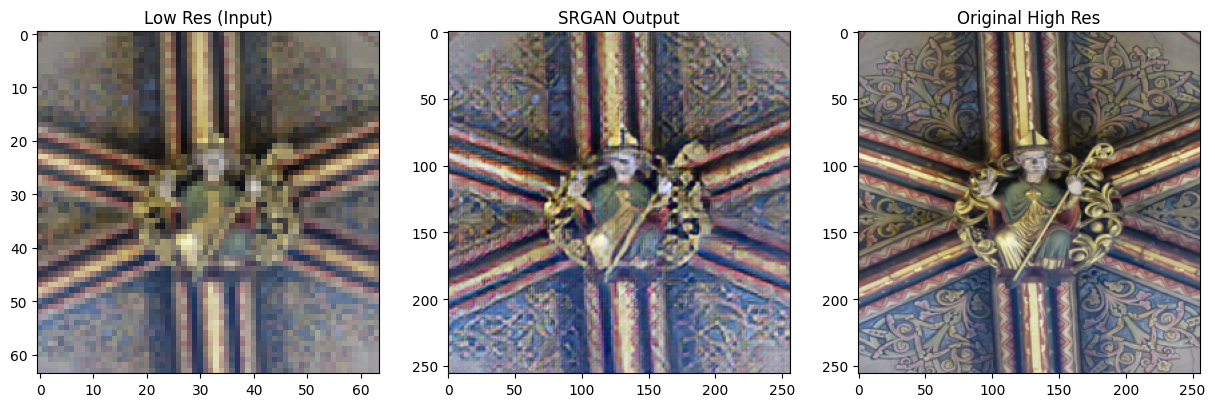

In [47]:
import torch
import matplotlib.pyplot as plt
import os
from PIL import Image
from torchvision import transforms
import random

# --- 1. RE-ESTABLISH DATASET (So 'dataset' is defined) ---
# Using the Flickr path you mentioned earlier
DATASET_PATH = r"D:\Coding\AD LAB\Minor Proj 6th sem\images\Flickr"

class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        self.files = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        self.hr_transform = transforms.Compose([
            transforms.Resize((256, 256), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        self.lr_transform = transforms.Compose([
            transforms.Resize((64, 64), Image.BICUBIC),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert("RGB")
        return self.lr_transform(img), self.hr_transform(img)

    def __len__(self): return len(self.files)

# Initialize the missing variable
dataset = SimpleDataset(DATASET_PATH)

# --- 2. LOAD THE SAVED MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure 'generator' or 'model' is initialized from our class
# Assuming 'Generator' class is already defined in our notebook
model = Generator().to(device)

try:
    model.load_state_dict(torch.load("srgan_generator.pth", map_location=device))
    model.eval()
    print("Model and Dataset loaded successfully!!!")
except FileNotFoundError:
    print("srgan_generator.pth not found. Did you run the training cell???")

# --- 3. SHOW THE PREDICTION ---
def show_prediction(index=0):
    lr, hr = dataset[index]
    
    with torch.no_grad():
        # Predict the High Res version
        fake_hr = model(lr.unsqueeze(0).to(device))

    # Helper to de-normalize and convert to numpy for plotting
    def to_img(t):
        t = t.squeeze().cpu().permute(1, 2, 0).numpy()
        t = (t * 0.5) + 0.5 # Undo normalization
        return t.clip(0, 1)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(to_img(lr))
    plt.title("Low Res (Input)")
    
    plt.subplot(1, 3, 2)
    plt.imshow(to_img(fake_hr))
    plt.title("SRGAN Output")
    
    plt.subplot(1, 3, 3)
    plt.imshow(to_img(hr))
    plt.title("Original High Res")
    plt.show()

# Run it!
random_idx = random.randint(0, len(dataset) - 1)
show_prediction(index=random_idx)

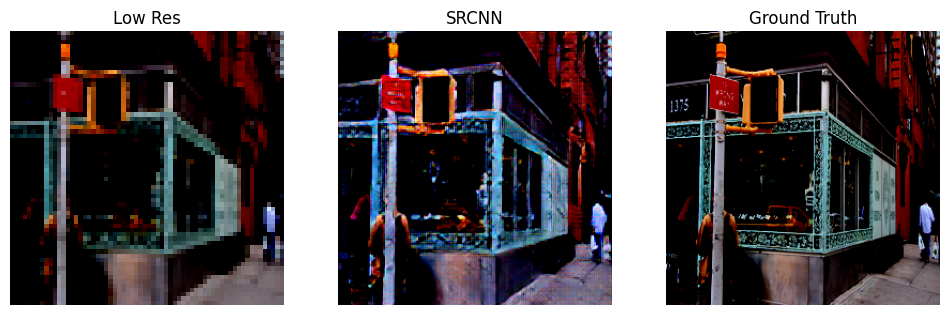

In [48]:
model.eval()
lr, hr = dataset[10]
model.eval()
lr,hr = dataset[10]
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

def show(img,title):
    img = img.clamp(0,1).numpy().transpose(1,2,0)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.figure(figsize=(12,4))
plt.subplot(131); show(lr,"Low Res")
plt.subplot(132); show(sr,"SRCNN")
plt.subplot(133); show(hr,"Ground Truth")
plt.show()

with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)


## 5. Results and Comparison


Loaded SRGAN Model successfully!!!


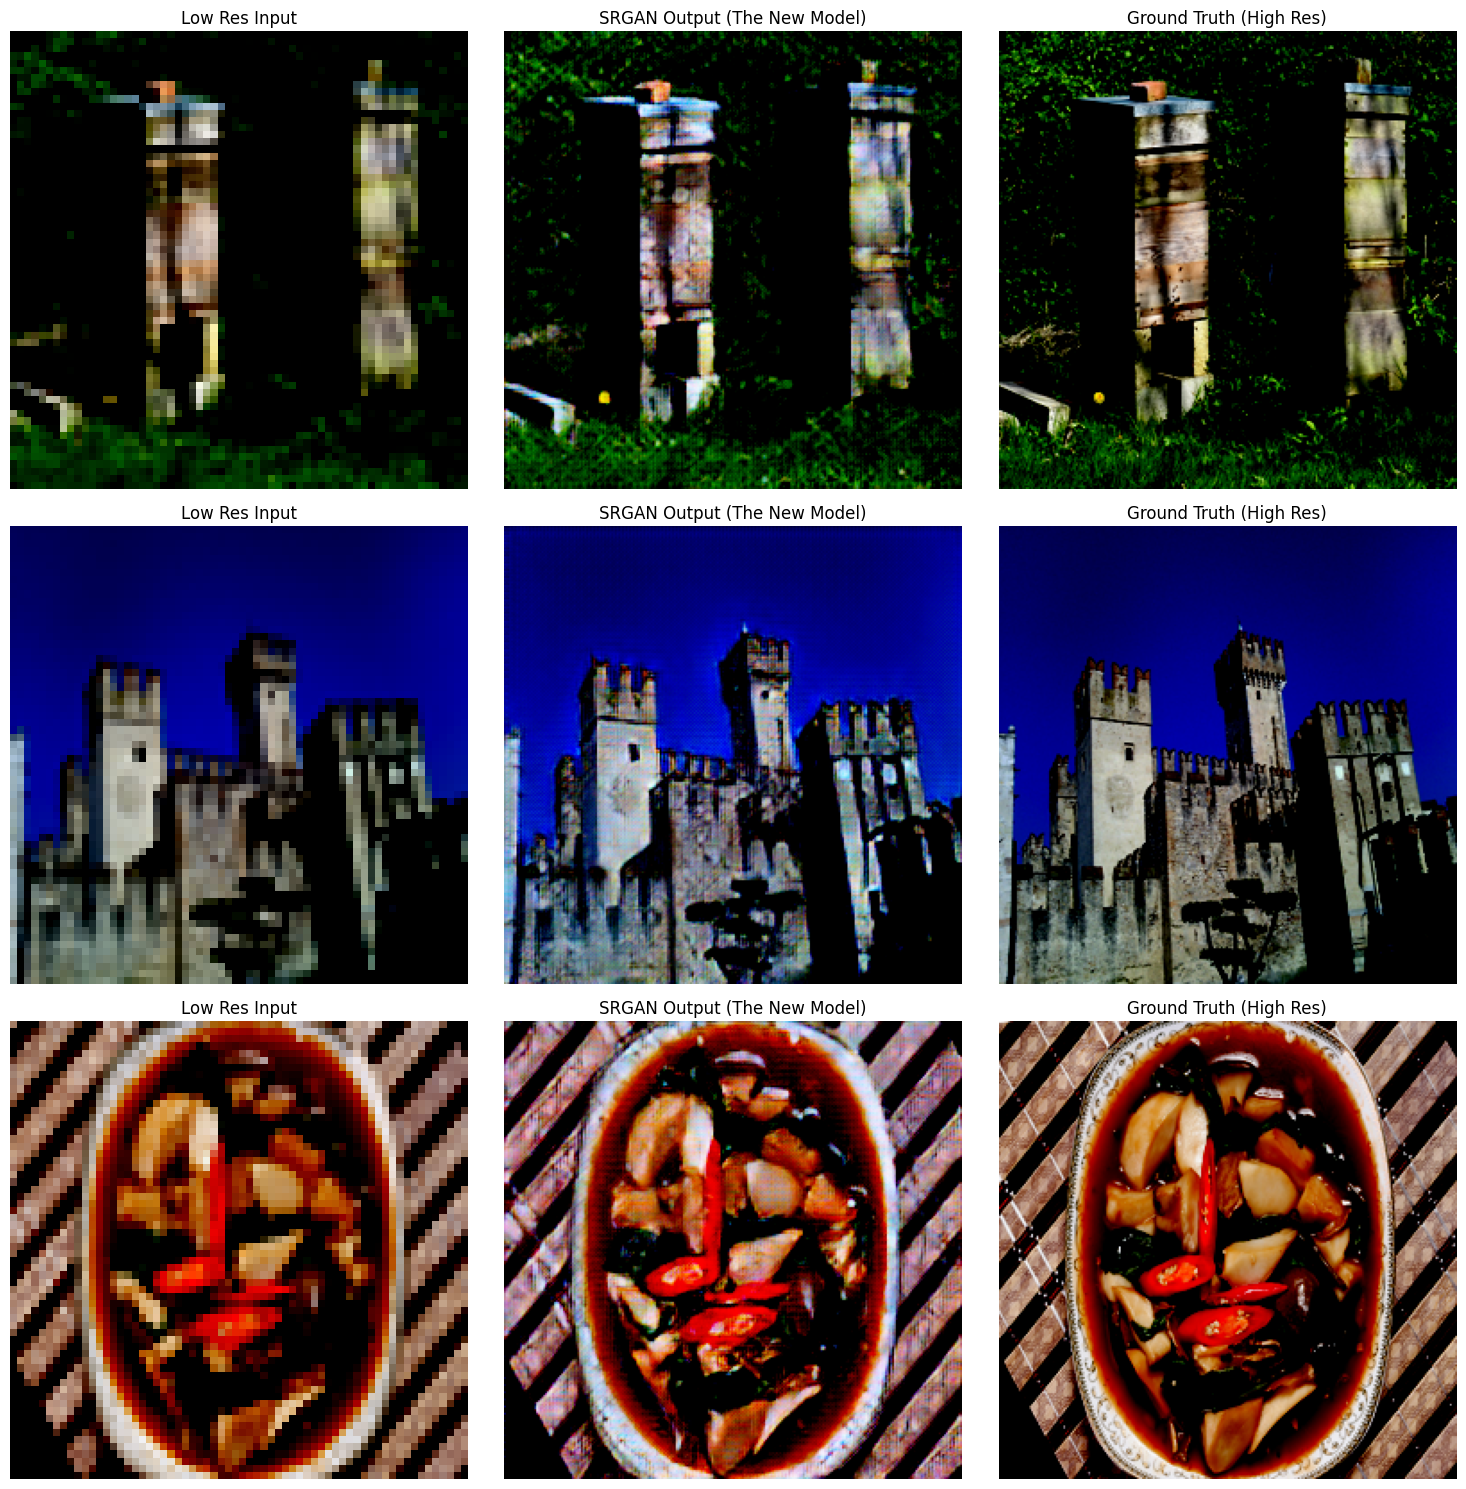

In [49]:
import matplotlib.pyplot as plt
import random

# 1. Force the model to be the New Generator
# (We re-create it to be 100% sure we aren't using the old one from memory)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Generator().to(device)

# 2. Load the SRGAN weights that we just trained
# --->> Note: If this fails, check if your file is named 'srgan_generator.pth' <<---
try:
    model.load_state_dict(torch.load("srgan_generator.pth", map_location=device))
    print("Loaded SRGAN Model successfully!!!")
except:
    print("Could not find 'srgan_generator.pth'. Make sure the training finished!")

model.eval()

# 3. Visualize
def show_results(n_images=3):
    plt.figure(figsize=(15, 5 * n_images))
    
    for i in range(n_images):
        random_idx = random.randint(0, len(dataset) - 1)
        lr, hr = dataset[random_idx] # Grab a random pair instead of [i]
        
        # Run the SRGAN Model
        with torch.no_grad():
            sr = model(lr.unsqueeze(0).to(device)).cpu().squeeze(0)

        # Prepare for plotting (Clamp to 0-1 range)
        lr_img = lr.permute(1, 2, 0).clamp(0, 1).numpy()
        sr_img = sr.permute(1, 2, 0).clamp(0, 1).numpy()
        hr_img = hr.permute(1, 2, 0).clamp(0, 1).numpy()

        # Plot
        plt.subplot(n_images, 3, i*3 + 1)
        plt.imshow(lr_img)
        plt.title("Low Res Input")
        plt.axis("off")

        plt.subplot(n_images, 3, i*3 + 2)
        plt.imshow(sr_img)
        plt.title("SRGAN Output (The New Model)") # Fixed Label
        plt.axis("off")

        plt.subplot(n_images, 3, i*3 + 3)
        plt.imshow(hr_img)
        plt.title("Ground Truth (High Res)")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()

show_results(3)

PSNR & SSIM (For single image)1

In [50]:
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import torch
import random

# 1. Initialize the metrics and move them to your GPU
psnr_calc = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_calc = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# 2. Pick a random image from your dataset
random_idx = random.randint(0, len(dataset) - 1)
lr, hr = dataset[random_idx]

# 3. Generate the Super-Res image
model.eval()
with torch.no_grad():
    sr = model(lr.unsqueeze(0).to(device))

# 4. Un-normalize the images from [-1, 1] back to standard [0, 1] for accurate metrics
sr_tensor = (sr + 1) / 2.0
hr_tensor = (hr.unsqueeze(0).to(device) + 1) / 2.0

# Clip the values strictly between 0 and 1 just to be safe
sr_tensor = torch.clamp(sr_tensor, 0, 1)
hr_tensor = torch.clamp(hr_tensor, 0, 1)

# 5. Calculate the scores!
psnr_score = psnr_calc(sr_tensor, hr_tensor)
ssim_score = ssim_calc(sr_tensor, hr_tensor)

print(f"--- Image Quality Metrics for Image {random_idx} ---")
print(f"PSNR: {psnr_score.item():.2f} dB")
print(f"SSIM: {ssim_score.item():.4f}")

--- Image Quality Metrics for Image 1721 ---
PSNR: 21.46 dB
SSIM: 0.4956


**PSINR & SSIM** (For teh whole data set average)

In [51]:
import json
import os
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import torch
from tqdm import tqdm 

def evaluate_model(model, dataset, device, metrics_path="saved_metrics.json"):
    model.eval()
    
    # Initialize metrics
    psnr_calc = PeakSignalNoiseRatio(data_range=1.0).to(device)
    ssim_calc = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    
    total_psnr = 0.0
    total_ssim = 0.0
    
    print("Evaluating dataset...")
    with torch.no_grad():
        for lr, hr in tqdm(dataset):
            # Format tensors: add batch dimension and move to device
            lr_tensor = lr.unsqueeze(0).to(device)
            hr_tensor = hr.unsqueeze(0).to(device)
            
            # Generate Super-Res image
            sr_tensor = model(lr_tensor)
            
            # Un-normalize from [-1, 1] to [0, 1]
            sr_eval = torch.clamp((sr_tensor + 1) / 2.0, 0, 1)
            hr_eval = torch.clamp((hr_tensor + 1) / 2.0, 0, 1)
            
            # Accumulate scores
            total_psnr += psnr_calc(sr_eval, hr_eval).item()
            total_ssim += ssim_calc(sr_eval, hr_eval).item()
            
    # Calculate averages
    avg_psnr = total_psnr / len(dataset)
    avg_ssim = total_ssim / len(dataset)
    
    print(f"\n--- Final Dataset Averages ---")
    print(f"Average PSNR: {avg_psnr:.2f} dB")
    print(f"Average SSIM: {avg_ssim:.4f}")
    
    # --- Saves the actual calculated scores to a file ---
    metrics_data = {"psnr": avg_psnr, "ssim": avg_ssim}
    with open(metrics_path, "w") as f:
        json.dump(metrics_data, f)
    print(f"(Scores securely saved to {metrics_path})")

# --- CONFIGURATION / TIME-SAVER ---
RUN_EVALUATION = False  
metrics_file = "saved_metrics.json"

# It will force a run if you tell it to, OR if the saved metrics file doesn't exist yet!
if RUN_EVALUATION or not os.path.exists(metrics_file):
    if not RUN_EVALUATION:
        print("No saved metrics found. Running math once to generate them...")
    evaluate_model(generator, dataset, device, metrics_file)
else:
    # --- Load and print the real scores from the file ---
    print("Skipping heavy math. Loading verified scores from last evaluation...")
    with open(metrics_file, "r") as f:
        saved_metrics = json.load(f)
        
    print(f"\n--- Loaded Dataset Averages ---")
    print(f"Average PSNR: {saved_metrics['psnr']:.2f} dB")
    print(f"Average SSIM: {saved_metrics['ssim']:.4f}")

Skipping heavy math. Loading verified scores from last evaluation...

--- Loaded Dataset Averages ---
Average PSNR: 20.48 dB
Average SSIM: 0.5321
